### Loading Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

seed = 25989
np.random.seed(seed)

### Generating Data Points

In [3]:
# Function to generate Random Points around a circle. (Inliers and Outliers)
def generate_circle_data(n_inliers=100, n_outliers=30, center=(0, 0), radius=5,
                         noise_std=0.2):
    cx, cy = center

    # Generating Inliers
    angles = np.random.uniform(0, 2*np.pi, n_inliers) # Generating angles from 0 to 2pi
    x_in = cx + radius * np.cos(angles)
    y_in = cy + radius * np.sin(angles)

    # Adding small noise to the inliers. (Normal)
    x_in += np.random.normal(0, noise_std, n_inliers)
    y_in += np.random.normal(0, noise_std, n_inliers)

    inliers = np.vstack((x_in, y_in)).T

    # Outliers (uniform random)
    x_out = np.random.uniform(cx - 2*radius, cx + 2*radius, n_outliers)
    y_out = np.random.uniform(cy - 2*radius, cy + 2*radius, n_outliers)
    outliers = np.vstack((x_out, y_out)).T

    data = np.vstack((inliers, outliers))
    np.random.shuffle(data)

    return data

## RANSAC for Circle

In [7]:
# Fitting Circle through 3 points
def fit_circle_3pts(p1, p2, p3):
    """
        Function to fit a circle, given 3 points (must be non-collinear).
        If collinear, function returns None. 
        Else, returns the center and radius of the circle.
    """
    A = np.array([[p1[0], p1[1], 1], [p2[0], p2[1], 1],[p3[0], p3[1], 1]])

    b = -np.array([
        p1[0]**2 + p1[1]**2,
        p2[0]**2 + p2[1]**2,
        p3[0]**2 + p3[1]**2
    ])

    # Check collinearity
    if np.linalg.matrix_rank(A) < 3:
        return None

    theta = np.linalg.solve(A, b)  # [a, b, c]

    a, b_, c = theta

    # Convert to geometric params
    cx = -a / 2
    cy = -b_ / 2
    r = np.sqrt(cx**2 + cy**2 - c)

    return (cx, cy, r)

# Residual Evaluation
def compute_residuals(data, params):
    """ For the given data and circle parameters, 
        we calculate the residuals """
    cx, cy, r = params
    x, y = data[:, 0], data[:, 1]
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    residuals = np.abs(distances - r)
    return residuals

# RANSAC Evaluation Model
def ransac_circle(data, num_iters=1000, threshold=0.3, top_k=5):
    n = data.shape[0]
    results = []

    for _ in range(num_iters):
        # Sample 3 points
        idx = np.random.choice(n, 3, replace=False)
        p1, p2, p3 = data[idx]
 
        # Fit circle through the 3 chosen points
        params = fit_circle_3pts(p1, p2, p3)
        if params is None:
            continue

        # Compute residuals and threshold to calculate the score.
        residuals = compute_residuals(data, params)
        inliers = residuals < threshold
        score = np.sum(inliers)

        results.append((params, score))

    # Sort by score descending
    results = sorted(results, key=lambda x: x[1], reverse=True)
    
    # Top K results for Visualization 
    top_results = results[:top_k]
    best_params = top_results[0][0]

    return top_results, best_params

In [6]:
# Visualizing the Results
def plot_circles(data, results, best_params):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot data
    ax.scatter(data[:, 0], data[:, 1], s=10, label='Data')

    theta = np.linspace(0, 2*np.pi, 200)

    # Plot top-K circles
    for (params, score) in results:
        cx, cy, r = params
        x = cx + r * np.cos(theta)
        y = cy + r * np.sin(theta)

        ax.plot(x, y, alpha=0.3, linewidth=1.5)

    # Plot best circle (opaque)
    cx, cy, r = best_params
    x = cx + r * np.cos(theta)
    y = cy + r * np.sin(theta)

    ax.plot(x, y, 'r', linewidth=1, label='Best Circle')

    ax.set_aspect('equal')
    ax.legend()
    plt.title("RANSAC Circle Fitting")
    plt.show()

### Evaluating RANSAC
1. Variance increases with the percentage of outliers in the Data. RANSAC starts giving more variance with percentage of outliers getting above 60%.
2. More data always helps (Variance of Model fit is less, with more data)
3. Variance between models seem to increase with radius. (Keeping everything else constant)
4. As we start making the noise (within inliers) more varying, the variance among the fit models increase. Even the accuracy of RANSAC gets affected.


Best Parameters: (np.float64(1.594291588887031), np.float64(-0.37189711806013925), np.float64(9.61011319310039))


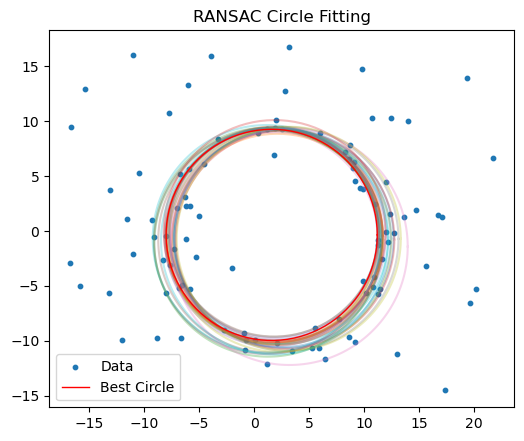

In [41]:
# Parameters
total_data = 100
percent_outlier = 0.40
num_outliers = int(percent_outlier * total_data)
num_inliers =  total_data - num_outliers

center = (2, -1)
rad = 10

# Generate data
data = generate_circle_data( n_inliers = num_inliers, n_outliers = num_outliers,
    center= center, radius= rad, noise_std=0.85)

# Run RANSAC
results, best_params = ransac_circle( data, num_iters=1000, threshold=0.3, top_k=30)

# print("Top K results (params, score):")
# for params, score in results:
#     print(f"Center: ({params[0]:.2f}, {params[1]:.2f}), "
#           f"Radius: {params[2]:.2f}, Score: {score}")

print("\nBest Parameters:", best_params)

# Visualize
plot_circles(data, results, best_params)

## IRLS for Circle

In [43]:
# Function to fit the parameters of the Circle given Weights for residuals. 
# (Closed Form as per Notes)
def weighted_circle_fit(data, weights):
    x = data[:, 0]
    y = data[:, 1]

    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x**2 + y**2)

    W = np.diag(weights)

    # Solve (A^T W A) theta = A^T W b
    AtW = A.T @ W
    theta = np.linalg.pinv(AtW @ A) @ (AtW @ b)

    a, b_, c = theta

    cx = -a / 2
    cy = -b_ / 2
    r = np.sqrt(cx**2 + cy**2 - c)

    return np.array([cx, cy, r])

In [44]:
# Computing Residuals of each data point, given the circle parameters
def compute_residuals_geom(data, params):
    cx, cy, r = params
    x = data[:, 0]
    y = data[:, 1]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    return dist - r

# Weights for Residuals related to the Custom Loss (As per Notes)
def weights_custom(residuals, a=1.0):
    r2 = residuals**2
    return (2 * a**2) / (r2 + a**2)**2

# Weights for Residuals related to the Huber Loss
def weights_huber(residuals, delta=1.0):
    abs_r = np.abs(residuals)
    weights = np.ones_like(residuals)

    mask = abs_r > delta
    weights[mask] = delta / abs_r[mask]

    return weights

### IRLS (Iteratively Reweighted Least Squares)

In [53]:
# IRLS Model Fit

def irls_circle(data, loss_type='custom', max_iters=50, tol=1e-6,
                param=1.0, init_params=None, verbose=True):

    # --- Initialization ---
    if init_params is None:
        weights = np.ones(len(data))
        params = weighted_circle_fit(data, weights)
    else:
        params = np.array(init_params)

    if verbose:
        print("\n--- IRLS Initialization ---")
        print(f"Initial Params: cx={params[0]:.4f}, cy={params[1]:.4f}, r={params[2]:.4f}")

    center_history = []
    center_history.append(params[:2].copy())  # store initial center

    for it in range(max_iters):
        residuals = compute_residuals_geom(data, params)

        # --- Select Type of Loss ---
        if loss_type == 'custom':
            weights = weights_custom(residuals, a=param)
        elif loss_type == 'huber':
            weights = weights_huber(residuals, delta=param)
        else:
            raise ValueError("Unknown loss type")

        new_params = weighted_circle_fit(data, weights)

        # store center trajectory
        center_history.append(new_params[:2].copy())

        # convergence check
        if np.linalg.norm(new_params - params) < tol:
            if verbose:
                print(f"Converged in {it+1} iterations")
            params = new_params
            break

        params = new_params

    if verbose:
        print("\nFinal Params:",
              f"cx={params[0]:.4f}, cy={params[1]:.4f}, r={params[2]:.4f}")

    return params, np.array(center_history)

In [54]:
# Visualizing the Results
def plot_irls_trajectory(data, center_history, best_params,
                         save = False, save_path=None,
                         filename= "irls_trajectory.png",
                         show=True):

    fig, ax = plt.subplots(figsize=(6, 6))

    # --- Plot data ---
    ax.scatter(data[:, 0], data[:, 1], s=10, label='Data')

    # --- Plot trajectory ---
    cx_hist = center_history[:, 0]
    cy_hist = center_history[:, 1]

    ax.plot(cx_hist, cy_hist, 'o--',linewidth = 1, color='blue', label='Center trajectory')

    # mark initial point
    ax.scatter(cx_hist[0], cy_hist[0], color='green', s=20, label='Initial', zorder=5)

    # mark final point
    ax.scatter(cx_hist[-1], cy_hist[-1], color='red', s=20, label='Final', zorder=5)

    # --- Plot best circle ---
    cx, cy, r = best_params
    theta = np.linspace(0, 2*np.pi, 200)
    x = cx + r * np.cos(theta)
    y = cy + r * np.sin(theta)

    ax.plot(x, y, 'r', linewidth=2, label='Best Circle')

    ax.set_aspect('equal')
    ax.legend()
    plt.title("IRLS Convergence (Center Trajectory)")

    # --- Save logic ---
    if save:
        if save_path is not None:
            if not os.path.exists(save_path):
                os.makedirs(save_path)
                print(f"Created directory: {save_path}")
    
            full_path = os.path.join(save_path, filename)
            plt.savefig(full_path, bbox_inches='tight')
            print(f"Saved plot to: {full_path}")

    if show:
        plt.show()
    else:
        plt.close()

### IRLS Evaluation
1. With Increasing Outlier (above 50%), model starts misbehaving (both losses). (Even with Good initialization)
2. Even with Good Initialization, the models start misbehaving as the inlier data gets corrupted.
3. RANSAC seems more robust to outliers than IRLS (Even with different losses)
4. With bad initialization, models misfit the data (even with small amount of outliers) .Custom Loss performs worse than Huber.


--- IRLS Initialization ---
Initial Params: cx=20.0000, cy=10.0000, r=2.0000
Converged in 21 iterations

Final Params: cx=17.1344, cy=5.5966, r=7.7820


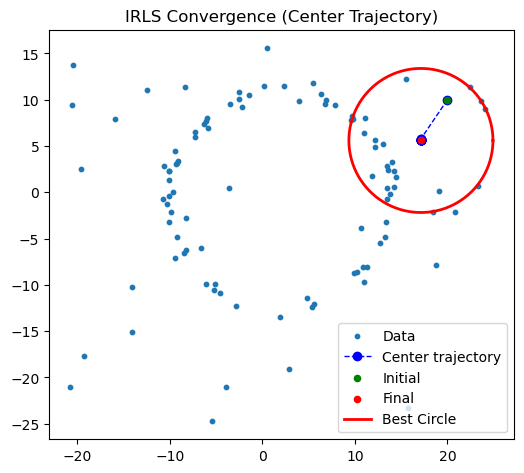

In [80]:
# Parameters
total_data = 100
percent_outlier = 0.30
num_outliers = int(percent_outlier * total_data)
num_inliers =  total_data - num_outliers

center = (2, -1)
rad = 12


# Generate data
data = generate_circle_data( n_inliers = num_inliers, n_outliers = num_outliers,
    center= center, radius= rad, noise_std=0.45)

# Initializations
init_good = [2.0, -1.0, 5.0]   # near true
init_bad = [20.0, 10.0, 2.0]   # far

# Run IRLS
params, center_hist = irls_circle( data, loss_type='custom',
    param=0.5, init_params=init_bad)

# Plot trajectory
plot_irls_trajectory( data, center_hist, params, save = False)